# XGBoost - combined dataset
Tuned `XGBRegressor` for `delay_s` on the `combined` dataset (Gold + Green + Red; Clough excluded — its stop ID can't be recovered causally). Row/feature counts are printed in the setup cell below rather than hard-coded here (v2 rebuilt the datasets with a whole-service-day split). Follows `plan/04_models/01_protocol.md` + `03_xgboost.md` (X1-X5).

Optuna searches for the hyperparameters that minimize MAE on a group-disjoint validation split of train, using XGBoost's built-in early stopping to pick `n_estimators` per trial. The winning config is then refit on the *full* train set and scored on test exactly once.

EDA context: delay is strongly route- and time-of-day-dependent (Green/Gold run consistently late, Red tracks ETAs closely; worst delays 16:00-18:00). `route_*` one-hot columns, `hour`/`tod_sin`/`tod_cos`, and the vehicle/stop entity embeddings are expected to carry a lot of the signal.

## X1 - Setup
Load the model-ready data and carve a group-disjoint validation split out of train (for Optuna's early stopping / objective). The test split is not touched here.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from xgboost import XGBRegressor

from mc_common import SMOKE, THREADS, budget, set_seed, load_model_ready, group_val_split, metrics, save_result

set_seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

DS = "combined"
d = load_model_ready(DS)

# group-disjoint inner split of TRAIN only, for early stopping + the tuning objective
X_tr, X_val, y_tr, y_val, g_tr = group_val_split(d.X_train, d.y_train, d.g_train, frac=0.2, seed=42)

print("SMOKE:", SMOKE, " THREADS:", THREADS)
print("train (full):", len(d.X_train), " -> inner-train:", len(X_tr), " inner-val:", len(X_val))
print("test (untouched until X4):", len(d.X_test))
print("n features:", len(d.features))


SMOKE: False  THREADS: 2
train (full): 81258  -> inner-train: 50096  inner-val: 31162
test (untouched until X4): 29141
n features: 50


## X2 - Optuna objective
One trial = one `XGBRegressor` fit on the inner-train split with early stopping against the inner-val split; the trial's score is validation MAE. `best_iteration` (picked by early stopping) is stashed as a trial attribute so X4 can refit on full train for exactly that many rounds - no early stopping, no test-set peeking, at the final-fit stage.

In [2]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 30, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100, log=True),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "objective": trial.suggest_categorical(
            "objective", ["reg:squarederror", "reg:pseudohubererror", "reg:absoluteerror"]
        ),
    }
    model = XGBRegressor(
        tree_method="hist",
        n_jobs=THREADS,
        n_estimators=budget(3000, 150),
        early_stopping_rounds=100,
        eval_metric="mae",
        random_state=42,
        **params,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    trial.set_user_attr("best_iteration", int(model.best_iteration))
    val_mae = metrics(y_val, model.predict(X_val))["mae"]
    return val_mae


## X3 - Study
`TPESampler(seed=42)`, single-threaded (Optuna `n_jobs=1` - the parallelism budget is spent inside each XGBoost fit via `THREADS`). Budgets are tiny under `MC_SMOKE=1`.

In [3]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=budget(60, 3), timeout=budget(1500, 60), n_jobs=1)

print(f"trials run: {len(study.trials)}")
print(f"best val MAE: {study.best_value:.2f}s")
print("best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print("best_iteration (from early stopping):", study.best_trial.user_attrs["best_iteration"])


trials run: 60
best val MAE: 195.21s
best params:
  learning_rate: 0.011698840531699476
  max_depth: 9
  min_child_weight: 4.095443418860987
  subsample: 0.8657503018516038
  colsample_bytree: 0.49038831853049697
  reg_alpha: 3.6158365574600186e-06
  reg_lambda: 0.030896757895791493
  gamma: 4.234738070314637
  objective: reg:pseudohubererror
best_iteration (from early stopping): 101


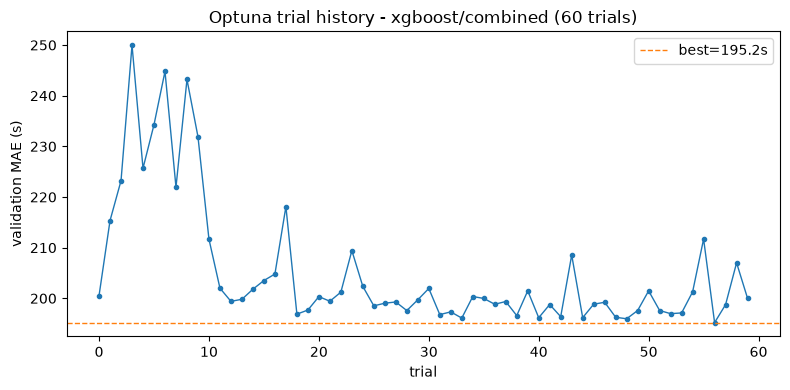

In [4]:
# trial history: validation MAE per trial, in search order
trials_df = study.trials_dataframe().sort_values("number")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trials_df["number"], trials_df["value"], marker="o", ms=3, lw=1)
ax.axhline(study.best_value, color="C1", ls="--", lw=1, label=f"best={study.best_value:.1f}s")
ax.set_xlabel("trial")
ax.set_ylabel("validation MAE (s)")
ax.set_title(f"Optuna trial history - xgboost/combined ({len(study.trials)} trials)")
ax.legend()
plt.tight_layout()
plt.show()


## X4 - Final fit + test
Refit on the **full** train split (inner-train + inner-val) with the winning hyperparameters and `n_estimators = best_iteration + 1` fixed - no early stopping, no eval set, so the test split is never involved in choosing anything. Predict test once and save via `save_result`.

In [5]:
best_params = dict(study.best_params)
n_estimators_final = study.best_trial.user_attrs["best_iteration"] + 1
best_trial_val_mae = study.best_trial.value
n_trials_complete = sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)

final_model = XGBRegressor(
    tree_method="hist",
    n_jobs=THREADS,
    n_estimators=n_estimators_final,
    random_state=42,
    importance_type="gain",
    **best_params,
)
final_model.fit(d.X_train, d.y_train)
y_pred = final_model.predict(d.X_test)

# cv_mae=None: this is a single group-disjoint holdout score, not a cross-validated one.
# The holdout figure (best trial's inner-val MAE) is recorded in extra instead.
result = save_result(
    DS, "xgboost", "XGBRegressor", d.y_test, y_pred,
    params={**best_params, "n_estimators": n_estimators_final},
    cv_mae=None,
    extra={"n_trials_complete": n_trials_complete, "best_trial_val_mae": best_trial_val_mae},
)

[combined__xgboost__XGBRegressor] test R2=0.3021  MAE=142.5s  RMSE=232.8s  (n=29141)


## X5 - Insight
Gain-based feature importance (top 20) and the final metrics table.

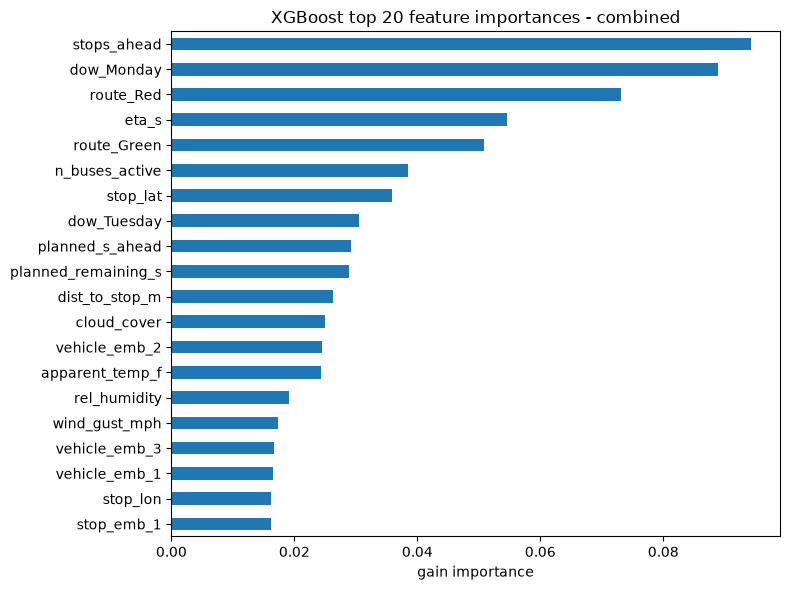

In [6]:
importances = pd.Series(final_model.feature_importances_, index=d.features).sort_values(ascending=False)
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20[::-1].plot.barh(ax=ax, color="C0")
ax.set_xlabel("gain importance")
ax.set_title("XGBoost top 20 feature importances - combined")
plt.tight_layout()
plt.show()


In [7]:
pd.DataFrame([{
    "dataset": DS, "family": result["family"], "model": result["model"],
    "r2": result["r2"], "mae": result["mae"], "rmse": result["rmse"],
    "n_test": result["n_test"], "cv_mae": result["cv_mae"],
    "best_trial_val_mae": result["extra"]["best_trial_val_mae"],
    "n_trials_complete": result["extra"]["n_trials_complete"],
}])

,dataset,family,model,r2,mae,rmse,n_test,cv_mae,best_trial_val_mae,n_trials_complete
0,combined,xgboost,XGBRegressor,0.302106,142.522485,232.7704,29141,None,195.205726,60
